# Hasil eksekusi Colab: 11_eksperimen

Dijalankan di VM Colab GPU T4 (sesi `d920cd`). Sel di bawah adalah kode notebook asli beserta outputnya.


In [ ]:
!pip install -q imbalanced-learn 2>/dev/null || true

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              ExtraTreesClassifier, RandomForestClassifier, VotingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, recall_score, precision_score
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as PipaImb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

FITUR_IMP = ["age", "hypertension", "heart_disease", "avg_glucose_level",
             "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]


def muat(mentah=False):
    """Preprocessing identik notebook 02."""
    url = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
           "tutorials/dataset/healthcare-dataset-stroke-data.csv")
    d = pd.read_csv(url).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()
    kosong = d.bmi.isna()
    if kosong.any():
        latih = d[~kosong]
        X_l = pd.get_dummies(latih[FITUR_IMP], drop_first=True)
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)).fit(X_l, latih.bmi)
        X_k = pd.get_dummies(d[kosong][FITUR_IMP], drop_first=True).reindex(
            columns=X_l.columns, fill_value=0)
        d.loc[kosong, "bmi"] = m.predict(X_k)
    if mentah:
        return d
    return pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True), d.stroke


ACUAN = lambda: make_pipeline(
    StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                         max_iter=5000, random_state=SEED))

X, y = muat()
mentah = muat(mentah=True)
print(f"Data: {X.shape[0]} baris, {X.shape[1]} fitur, positif {y.sum()} ({y.mean()*100:.2f}%)")

Data: 5109 baris, 15 fitur, positif 249 (4.87%)


In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
s = cross_validate(ACUAN(), X, y, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1)

print(f"AUC : {s['test_roc_auc'].mean():.4f} ± {s['test_roc_auc'].std():.4f}")
print(f"AP  : {s['test_average_precision'].mean():.4f} ± {s['test_average_precision'].std():.4f}")
print()
print("Simpangan baku AUC 0,018 itu BESAR. Kalau kita membandingkan dua model lewat")
print("rata-rata masing-masing, peningkatan sekecil 0,01 akan tenggelam dalam derau.")
print()
print("Catatan: AP (average precision) lebih tepat daripada ROC-AUC untuk kejadian")
print("langka, karena tidak dibesar-besarkan oleh 95% kelas negatif yang mudah ditebak.")

AUC : 0.8409 ± 0.0180
AP  : 0.2024 ± 0.0328

Simpangan baku AUC 0,018 itu BESAR. Kalau kita membandingkan dua model lewat
rata-rata masing-masing, peningkatan sekecil 0,01 akan tenggelam dalam derau.

Catatan: AP (average precision) lebih tepat daripada ROC-AUC untuk kejadian
langka, karena tidak dibesar-besarkan oleh 95% kelas negatif yang mudah ditebak.


In [ ]:
def skor_lipatan(model, X, y, cv):
    s = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return s["test_roc_auc"], s["test_average_precision"]


def banding(kandidat, nama, X_kandidat=None, acuan=None, cv=cv):
    """Uji berpasangan terhadap model acuan. 'Nyata' berarti selisihnya lebih dari
    dua galat baku dari nol -- di bawah itu, belum bisa disebut peningkatan."""
    acuan = acuan or ACUAN()
    Xk = X if X_kandidat is None else X_kandidat

    auc_a, ap_a = skor_lipatan(acuan, X, y, cv)
    auc_k, ap_k = skor_lipatan(kandidat, Xk, y, cv)

    h = {"Gagasan": nama}
    for label, a, k in [("AUC", auc_a, auc_k), ("AP", ap_a, ap_k)]:
        d = k - a
        se = d.std(ddof=1) / np.sqrt(len(d))
        h[f"{label} acuan"] = round(a.mean(), 4)
        h[f"{label} baru"] = round(k.mean(), 4)
        h[f"Δ{label}"] = round(d.mean(), 4)
        h[f"±{label}"] = round(se, 4)
        h[f"{label} nyata?"] = "YA" if abs(d.mean()) > 2 * se else "tidak"
    return h

In [ ]:
uji_alat = [
    banding(DummyClassifier(strategy="stratified", random_state=SEED),
            "Model acak: beda BESAR, harus tertangkap"),
    banding(make_pipeline(StandardScaler(),
                          LogisticRegression(C=1.0, penalty="l1", solver="liblinear",
                                             max_iter=5000, random_state=SEED)),
            "C=1.0 vs C=0.1: beda sedang"),
    banding(make_pipeline(StandardScaler(),
                          LogisticRegression(C=0.15, penalty="l1", solver="liblinear",
                                             max_iter=5000, random_state=SEED)),
            "C=0.15 vs C=0.1: beda SANGAT tipis"),
    banding(make_pipeline(StandardScaler(),
                          LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                             max_iter=5000, random_state=SEED + 1)),
            "Model identik (seed beda; liblinear deterministik)"),
]
print(f"Jumlah lipatan: {cv.get_n_splits()}  (5 pembagian x 5 pengulangan)")
pd.DataFrame(uji_alat)[["Gagasan", "ΔAUC", "±AUC", "AUC nyata?"]]

Jumlah lipatan: 25  (5 pembagian x 5 pengulangan)


,Gagasan,ΔAUC,±AUC,AUC nyata?
0,"Model acak: beda BESAR, harus tertangkap",-0.3414,0.0037,YA
1,C=1.0 vs C=0.1: beda sedang,-0.0019,0.0005,YA
2,C=0.15 vs C=0.1: beda SANGAT tipis,-0.0004,0.0002,YA
3,Model identik (seed beda; liblinear determinis...,-0.0000,0.0000,tidak


In [ ]:
def tambah(kolom):
    return pd.concat([X, pd.DataFrame(kolom, index=X.index)], axis=1)


GAGASAN_FITUR = {
    "Kategori glukosa (ADA)": {"glukosa_kat": np.digitize(mentah.avg_glucose_level, [100, 126])},
    "Kategori BMI (WHO)": {"bmi_kat": np.digitize(mentah.bmi, [18.5, 25, 30])},
    "Usia kuadrat": {"usia2": mentah.age ** 2},
    "Penanda lansia (>=60)": {"lansia": (mentah.age >= 60).astype(int)},
    "Usia × hipertensi": {"usia_x_ht": mentah.age * mentah.hypertension},
    "Usia × penyakit jantung": {"usia_x_pj": mentah.age * mentah.heart_disease},
    "Jumlah faktor risiko": {"n_risiko": (
        mentah.hypertension + mentah.heart_disease
        + (mentah.avg_glucose_level >= 126).astype(int)
        + (mentah.bmi >= 30).astype(int)
        + mentah.smoking_status.isin(["smokes", "formerly smoked"]).astype(int))},
}

hasil_fitur = [banding(ACUAN(), nama, X_kandidat=tambah(kol))
               for nama, kol in GAGASAN_FITUR.items()]

semua = {}
for kol in GAGASAN_FITUR.values():
    semua.update(kol)
hasil_fitur.append(banding(ACUAN(), "SEMUA digabung", X_kandidat=tambah(semua)))

pd.DataFrame(hasil_fitur)[["Gagasan", "ΔAUC", "±AUC", "AUC nyata?",
                           "ΔAP", "±AP", "AP nyata?"]]

,Gagasan,ΔAUC,±AUC,AUC nyata?,ΔAP,±AP,AP nyata?
0,Kategori glukosa (ADA),-0.0002,0.0002,tidak,-0.0005,0.0010,tidak
1,Kategori BMI (WHO),-0.0001,0.0001,tidak,-0.0002,0.0002,tidak
2,Usia kuadrat,-0.0001,0.0002,tidak,0.0016,0.0008,YA
3,Penanda lansia (>=60),-0.0000,0.0000,tidak,-0.0000,0.0000,tidak
4,Usia × hipertensi,-0.0003,0.0001,YA,-0.0006,0.0003,YA
5,Usia × penyakit jantung,0.0000,0.0000,tidak,0.0000,0.0000,tidak
6,Jumlah faktor risiko,-0.0001,0.0002,tidak,0.0001,0.0011,tidak
7,SEMUA digabung,-0.0002,0.0004,tidak,-0.0018,0.0013,tidak


In [ ]:
LR = lambda: LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                max_iter=5000, random_state=SEED)

CARA_SEIMBANG = {
    "class_weight='balanced'": make_pipeline(
        StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                             max_iter=5000, class_weight="balanced",
                                             random_state=SEED)),
    "SMOTE": PipaImb([("s", StandardScaler()), ("r", SMOTE(random_state=SEED)), ("m", LR())]),
    "ADASYN": PipaImb([("s", StandardScaler()), ("r", ADASYN(random_state=SEED)), ("m", LR())]),
    "BorderlineSMOTE": PipaImb([("s", StandardScaler()), ("r", BorderlineSMOTE(random_state=SEED)), ("m", LR())]),
    "SMOTEENN": PipaImb([("s", StandardScaler()), ("r", SMOTEENN(random_state=SEED)), ("m", LR())]),
    "SMOTETomek": PipaImb([("s", StandardScaler()), ("r", SMOTETomek(random_state=SEED)), ("m", LR())]),
    "Random Undersampling": PipaImb([("s", StandardScaler()), ("r", RandomUnderSampler(random_state=SEED)), ("m", LR())]),
}

hasil_seimbang = [banding(m, nama) for nama, m in CARA_SEIMBANG.items()]
pd.DataFrame(hasil_seimbang)[["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?",
                              "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,class_weight='balanced',0.8389,-0.0020,YA,0.2013,-0.0011,tidak
1,SMOTE,0.8363,-0.0046,YA,0.2039,0.0016,tidak
2,ADASYN,0.8362,-0.0047,YA,0.2011,-0.0013,tidak
3,BorderlineSMOTE,0.8373,-0.0036,YA,0.1978,-0.0045,tidak
4,SMOTEENN,0.8368,-0.0041,YA,0.2003,-0.0021,tidak
5,SMOTETomek,0.8362,-0.0046,YA,0.2036,0.0013,tidak
6,Random Undersampling,0.8368,-0.0041,YA,0.1975,-0.0049,tidak


In [ ]:
GB = lambda: GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                        max_depth=2, random_state=SEED)

GABUNGAN = {
    "Voting LR + GB": VotingClassifier(
        [("lr", make_pipeline(StandardScaler(), LR())),
         ("gb", make_pipeline(StandardScaler(), GB()))], voting="soft"),
    "Voting LR + GB + RF": VotingClassifier(
        [("lr", make_pipeline(StandardScaler(), LR())),
         ("gb", make_pipeline(StandardScaler(), GB())),
         ("rf", RandomForestClassifier(n_estimators=200, max_depth=6,
                                       random_state=SEED, n_jobs=-1))], voting="soft"),
    "BalancedRandomForest": BalancedRandomForestClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1),
}

pd.DataFrame([banding(m, nama) for nama, m in GABUNGAN.items()])[
    ["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?", "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,Voting LR + GB,0.8411,0.0002,tidak,0.1960,-0.0063,tidak
1,Voting LR + GB + RF,0.8409,0.0000,tidak,0.1958,-0.0065,tidak
2,BalancedRandomForest,0.8261,-0.0148,YA,0.1652,-0.0372,YA


In [ ]:
LEBIH_KUAT = {
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
    "HistGB dalam (depth 8)": HistGradientBoostingClassifier(max_depth=8, random_state=SEED),
    "ExtraTrees 500 pohon": ExtraTreesClassifier(n_estimators=500, random_state=SEED, n_jobs=-1),
    "RandomForest dalam": RandomForestClassifier(n_estimators=500, max_depth=12,
                                                 random_state=SEED, n_jobs=-1),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "LDA sebagai pengklasifikasi": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "Gradient Boosting (notebook 07)": make_pipeline(StandardScaler(), GB()),
}

hasil_kuat = [banding(m, nama) for nama, m in LEBIH_KUAT.items()]
pd.DataFrame(hasil_kuat)[["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?",
                          "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,HistGradientBoosting,0.8167,-0.0242,YA,0.1632,-0.0391,YA
1,HistGB dalam (depth 8),0.8170,-0.0238,YA,0.1661,-0.0363,YA
2,ExtraTrees 500 pohon,0.7686,-0.0723,YA,0.1240,-0.0784,YA
3,RandomForest dalam,0.8140,-0.0269,YA,0.1645,-0.0378,YA
4,Naive Bayes,0.8073,-0.0336,YA,0.1691,-0.0332,YA
5,LDA sebagai pengklasifikasi,0.8334,-0.0075,YA,0.2037,0.0014,tidak
6,Gradient Boosting (notebook 07),0.8399,-0.0010,tidak,0.1843,-0.0181,YA


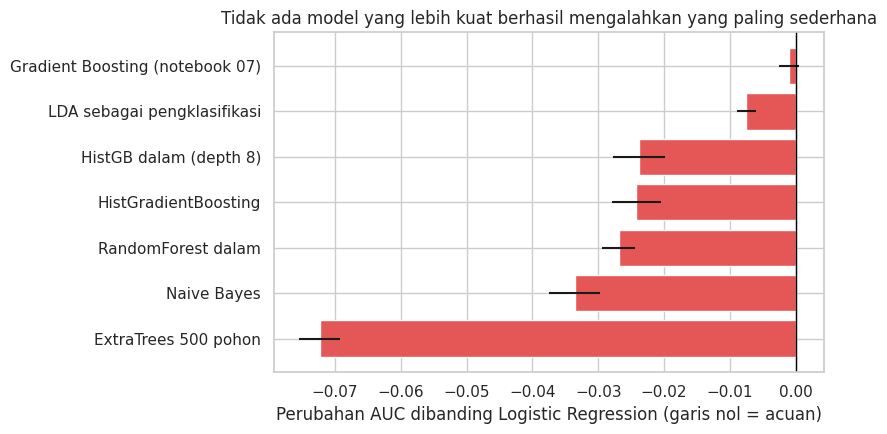

In [ ]:
ringkas = pd.DataFrame(hasil_kuat).sort_values("AUC baru", ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
warna = ["#4C78A8" if v >= 0 else "#E45756" for v in ringkas["ΔAUC"]]
ax.barh(ringkas.Gagasan, ringkas["ΔAUC"], xerr=ringkas["±AUC"], color=warna)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Perubahan AUC dibanding Logistic Regression (garis nol = acuan)")
ax.set_title("Tidak ada model yang lebih kuat berhasil mengalahkan yang paling sederhana")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid_hgb = {
    "max_iter": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, None],
    "min_samples_leaf": [20, 50],
    "l2_regularization": [0.0, 1.0],
}
cari_hgb = GridSearchCV(HistGradientBoostingClassifier(random_state=SEED), grid_hgb,
                        scoring="roc_auc", n_jobs=-1,
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
cari_hgb.fit(X, y)
print("HistGB terbaik :", cari_hgb.best_params_)
print(f"AUC saat pencarian: {cari_hgb.best_score_:.4f}")

hasil_adil = banding(HistGradientBoostingClassifier(random_state=SEED, **cari_hgb.best_params_),
                     "HistGB DISETEL vs Logistic Regression")
pd.DataFrame([hasil_adil])[["Gagasan", "AUC acuan", "AUC baru", "ΔAUC", "±AUC",
                            "AUC nyata?", "AP acuan", "AP baru", "ΔAP", "AP nyata?"]]

HistGB terbaik : {'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 50}
AUC saat pencarian: 0.8444


,Gagasan,AUC acuan,AUC baru,ΔAUC,±AUC,AUC nyata?,AP acuan,AP baru,ΔAP,AP nyata?
0,HistGB DISETEL vs Logistic Regression,0.8409,0.8418,0.0009,0.0017,tidak,0.2024,0.193,-0.0094,YA


In [ ]:
cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED)

p_mentah = cross_val_predict(ACUAN(), X, y, cv=cv1, method="predict_proba")[:, 1]
p_iso = cross_val_predict(CalibratedClassifierCV(ACUAN(), method="isotonic", cv=5),
                          X, y, cv=cv1, method="predict_proba")[:, 1]
p_sig = cross_val_predict(CalibratedClassifierCV(ACUAN(), method="sigmoid", cv=5),
                          X, y, cv=cv1, method="predict_proba")[:, 1]

print("Skor Brier (makin KECIL makin jujur):")
for nama, p in [("Tanpa kalibrasi", p_mentah), ("Kalibrasi isotonik", p_iso),
                ("Kalibrasi sigmoid", p_sig)]:
    print(f"  {nama:20} {brier_score_loss(y, p):.5f}")

Skor Brier (makin KECIL makin jujur):
  Tanpa kalibrasi      0.04240
  Kalibrasi isotonik   0.04281
  Kalibrasi sigmoid    0.04242


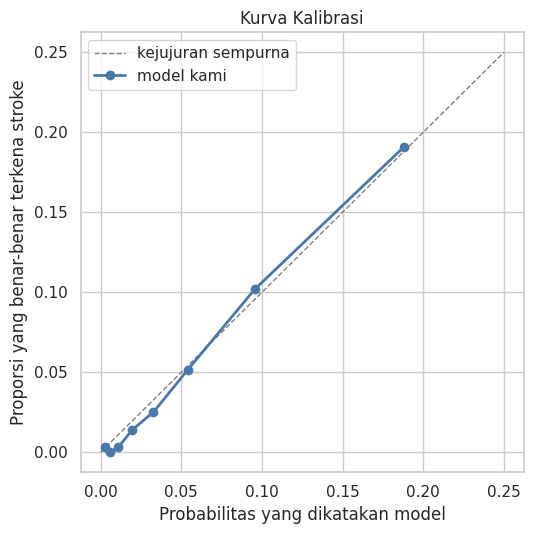

,model bilang,kenyataan
0,0.3,0.3
1,0.6,0.0
2,1.1,0.3
3,2.0,1.4
4,3.3,2.5
5,5.4,5.2
6,9.6,10.2
7,18.8,19.1


In [ ]:
frak, rata = calibration_curve(y, p_mentah, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, .25], [0, .25], "--", color="grey", lw=1, label="kejujuran sempurna")
ax.plot(rata, frak, "o-", color="#4C78A8", lw=2, label="model kami")
ax.set_xlabel("Probabilitas yang dikatakan model")
ax.set_ylabel("Proporsi yang benar-benar terkena stroke")
ax.set_title("Kurva Kalibrasi")
ax.legend(); plt.tight_layout(); plt.show()

pd.DataFrame({"model bilang": (rata * 100).round(1),
              "kenyataan": (frak * 100).round(1)})

In [ ]:
def ambang_termurah(y, p, rasio):
    """rasio = berapa kali melewatkan pasien stroke lebih merugikan daripada
    memanggil orang sehat. Kembalikan ambang dengan biaya harapan terkecil."""
    terbaik, biaya_min = 0.5, np.inf
    for t in np.unique(np.round(p, 4)):
        pred = (p >= t).astype(int)
        fn = int(((pred == 0) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        biaya = rasio * fn + fp
        if biaya < biaya_min:
            biaya_min, terbaik = biaya, t
    return terbaik, biaya_min


baris = []
for rasio in [1, 5, 10, 20, 50, 100]:
    t, b = ambang_termurah(y.values, p_mentah, rasio)
    pred = (p_mentah >= t).astype(int)
    baris.append({
        "Rugi FN : FP": f"{rasio} : 1", "Ambang": round(t, 4),
        "recall": round(recall_score(y, pred), 3),
        "precision": round(precision_score(y, pred, zero_division=0), 3),
        "ditandai %": round(100 * pred.mean(), 1),
        "biaya total": int(b),
    })

pd.DataFrame(baris)

,Rugi FN : FP,Ambang,recall,precision,ditandai %,biaya total
0,1 : 1,0.3887,0.008,0.500,0.1,249
1,5 : 1,0.1669,0.317,0.225,6.9,1122
2,10 : 1,0.0863,0.687,0.166,20.1,1638
3,20 : 1,0.0542,0.831,0.131,30.9,2212
4,50 : 1,0.0351,0.920,0.108,41.7,2900
5,100 : 1,0.0208,0.972,0.087,54.7,3255


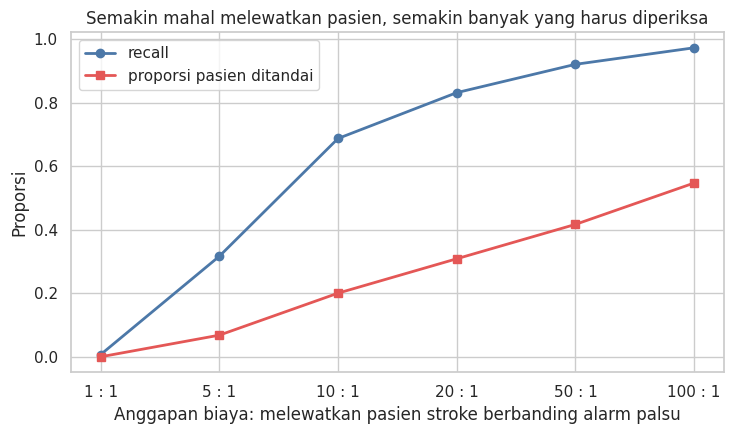

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
t = pd.DataFrame(baris)
ax.plot(range(len(t)), t["recall"], "o-", label="recall", color="#4C78A8", lw=2)
ax.plot(range(len(t)), t["ditandai %"] / 100, "s-", label="proporsi pasien ditandai",
        color="#E45756", lw=2)
ax.set_xticks(range(len(t))); ax.set_xticklabels(t["Rugi FN : FP"])
ax.set_xlabel("Anggapan biaya: melewatkan pasien stroke berbanding alarm palsu")
ax.set_ylabel("Proporsi")
ax.set_title("Semakin mahal melewatkan pasien, semakin banyak yang harus diperiksa")
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
dewasa = (mentah.age >= 18).values
X_dewasa, y_dewasa = X[dewasa], y[dewasa]

print(f"Dibuang     : {(~dewasa).sum()} baris berusia < 18 tahun")
print(f"Kasus stroke pada baris yang dibuang: {int(y[~dewasa].sum())}")
print()

baris_umur = []
for label, Xu, yu in [("Semua umur", X, y), ("Dewasa saja (>=18)", X_dewasa, y_dewasa)]:
    s = cross_validate(ACUAN(), Xu, yu, cv=cv,
                       scoring=["roc_auc", "average_precision"], n_jobs=-1)
    baris_umur.append({
        "Data": label, "baris": len(yu), "stroke": int(yu.sum()),
        "% stroke": round(100 * yu.mean(), 2),
        "AUC": round(s["test_roc_auc"].mean(), 4),
        "±AUC": round(s["test_roc_auc"].std(), 4),
        "AP": round(s["test_average_precision"].mean(), 4),
    })
pd.DataFrame(baris_umur)

Dibuang     : 856 baris berusia < 18 tahun
Kasus stroke pada baris yang dibuang: 2



,Data,baris,stroke,% stroke,AUC,±AUC,AP
0,Semua umur,5109,249,4.87,0.8409,0.0180,0.2024
1,Dewasa saja (>=18),4253,247,5.81,0.8152,0.0248,0.2076
